# Diagnostico de outliers en W07

Compara W07 con todos los demas trabajadores procesados. El objetivo es separar problemas de calidad, valores extremos y cambios legitimos de distribucion. No elimina datos automaticamente.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT_CANDIDATES = [Path.cwd().parent if Path.cwd().name == 'nootebooks' else Path.cwd(), Path.cwd() / 'new']
DATA_DIR = next((path for path in ROOT_CANDIDATES if (path / 'W07').exists()), ROOT_CANDIDATES[0])
TARGET_WORKER = 'W07'
FEATURE_COLUMNS = [
    'ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z',
    'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z',
    'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z',
]
RAW_FEATURE_COLUMNS = [column[:-2] for column in FEATURE_COLUMNS]
print(f'Directorio de datos: {DATA_DIR}')

Directorio de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new


## Carga y calidad basica

Se revisan ventanas, `HR_valid`, `FatigueIndex` y missingness de las features. Una diferencia de calidad no debe confundirse con un outlier fisiologico.

In [3]:
worker_files = {worker_dir.name: worker_dir / 'PROCESSED' / 'combined_features_1min.csv' for worker_dir in sorted(DATA_DIR.glob('W[0-9][0-9]')) if (worker_dir / 'PROCESSED' / 'combined_features_1min.csv').exists()}
if TARGET_WORKER not in worker_files: raise FileNotFoundError(f'No se encontro {TARGET_WORKER}')
data = {worker: pd.read_csv(path) for worker, path in worker_files.items()}
required = {'HR_valid', 'FatigueIndex', *FEATURE_COLUMNS, *RAW_FEATURE_COLUMNS}
for worker, frame in data.items():
    missing = sorted(required - set(frame.columns))
    if missing: raise ValueError(f'{worker}: faltan columnas {missing}')
    frame['Worker'] = worker
all_data = pd.concat(data.values(), ignore_index=True)
quality_rows = []
for worker, frame in data.items():
    values = frame[FEATURE_COLUMNS].apply(pd.to_numeric, errors='coerce')
    quality_rows.append({'Worker': worker, 'Windows': len(frame), 'HR_valid_%': 100 * frame['HR_valid'].eq(1).mean(), 'FatigueIndex_valid_%': 100 * pd.to_numeric(frame['FatigueIndex'], errors='coerce').notna().mean(), 'Feature_missing_%': 100 * values.isna().mean().mean(), 'Rows_with_any_missing_%': 100 * values.isna().any(axis=1).mean()})
quality_df = pd.DataFrame(quality_rows).sort_values('Worker')
display(quality_df.round(2))

,Worker,Windows,HR_valid_%,FatigueIndex_valid_%,Feature_missing_%,Rows_with_any_missing_%
0,W00,104,100.00,100.0,0.12,0.96
1,W01,637,18.84,100.0,55.58,81.95
2,W02,603,17.08,100.0,56.83,83.58
3,W03,407,99.02,100.0,0.71,1.23
4,W04,562,9.61,100.0,61.59,91.99
5,W05,74,45.95,100.0,35.56,56.76
6,W06,35,88.57,100.0,7.14,17.14
7,W07,67,100.00,100.0,0.19,1.49
8,W08,133,9.02,100.0,62.55,91.73
9,W09,16,37.50,100.0,38.67,75.00


## Comparacion de variables crudas y normalizadas

Las tablas muestran si la diferencia de W07 ya existe en la medicion original o aparece despues del calculo de z-score.

In [4]:
def summarize(columns):
    rows = []
    for feature in columns:
        for worker, frame in data.items():
            values = pd.to_numeric(frame[feature], errors='coerce').dropna()
            rows.append({'Feature': feature, 'Worker': worker, 'N': len(values), 'Mean': values.mean(), 'Median': values.median(), 'Std': values.std(), 'P01': values.quantile(.01), 'P99': values.quantile(.99), 'Min': values.min(), 'Max': values.max()})
    return pd.DataFrame(rows)

z_summary = summarize(FEATURE_COLUMNS)
raw_summary = summarize(RAW_FEATURE_COLUMNS)
def compare(summary):
    w07 = summary[summary.Worker == TARGET_WORKER].set_index('Feature')
    others = summary[summary.Worker != TARGET_WORKER].groupby('Feature').mean(numeric_only=True)
    return w07[['N', 'Mean', 'Median', 'Std', 'P01', 'P99', 'Min', 'Max']].join(others[['Mean', 'Median', 'Std', 'P01', 'P99', 'Min', 'Max']], lsuffix='_W07', rsuffix='_others_mean')
print('Features normalizadas (_z)')
display(compare(z_summary).round(3))
print('Features crudas')
display(compare(raw_summary).round(3))

Features normalizadas (_z)


,N,Mean_W07,Median_W07,Std_W07,P01_W07,P99_W07,Min_W07,Max_W07,Mean_others_mean,Median_others_mean,Std_others_mean,P01_others_mean,P99_others_mean,Min_others_mean,Max_others_mean
Feature,,,,,,,,,,,,,,,
ECG_energy_z,67,-0.397,-0.574,0.565,-0.723,1.693,-0.730,3.133,9.620,-0.186,42.699,-0.837,166.819,-0.898,348.028
ECG_mean_z,67,0.461,0.580,0.526,-1.362,0.693,-3.328,0.697,1.458,0.804,4.166,-2.557,17.485,-9.316,27.645
ECG_missing_peaks_z,67,-0.074,-0.215,1.198,-1.451,4.166,-1.530,8.030,0.332,0.061,1.883,-1.869,5.950,-1.999,7.790
ECG_range_z,67,-0.022,-0.518,2.062,-1.842,8.317,-2.117,12.347,2.192,0.176,6.098,-0.948,28.830,-1.585,33.401
ECG_samp_ent_z,67,0.309,0.111,0.933,-1.152,3.411,-1.187,4.097,0.397,0.021,1.891,-2.275,5.541,-2.519,6.990
ECG_std_z,67,-0.506,-0.739,0.718,-1.104,1.778,-1.130,2.016,2.216,0.298,7.037,-0.866,31.947,-1.009,49.504
HR_max_z,67,0.843,0.546,1.514,-1.513,7.577,-2.547,7.878,1.228,0.366,2.816,-1.482,10.356,-1.614,10.920
HR_mean_z,67,0.875,0.840,0.932,-1.386,3.025,-1.412,3.112,0.917,0.827,1.630,-1.653,4.342,-1.848,4.725
HR_min_z,67,0.498,0.584,1.275,-3.159,3.025,-4.356,3.448,0.740,0.880,1.826,-3.388,3.936,-4.801,4.222


Features crudas


,N,Mean_W07,Median_W07,Std_W07,P01_W07,P99_W07,Min_W07,Max_W07,Mean_others_mean,Median_others_mean,Std_others_mean,P01_others_mean,P99_others_mean,Min_others_mean,Max_others_mean
Feature,,,,,,,,,,,,,,,
ECG_energy,67,0.054,0.045,0.026,0.038,0.151,0.038,0.218,1.631,0.094,6.005,0.056,24.819,0.053,45.269
ECG_mean,67,0.038,0.051,0.058,-0.162,0.064,-0.377,0.064,-0.057,-0.085,0.167,-0.209,0.586,-0.391,1.030
ECG_missing_peaks,67,24.179,23.000,10.029,12.660,59.660,12.000,92.000,24.475,21.722,12.475,11.251,60.118,10.667,69.222
ECG_range,67,2.350,2.201,0.618,1.804,4.848,1.722,6.055,5.836,3.138,6.481,2.079,27.776,1.943,31.530
ECG_samp_ent,67,0.396,0.370,0.122,0.205,0.802,0.200,0.892,0.236,0.210,0.127,0.061,0.581,0.046,0.672
ECG_std,67,0.218,0.207,0.034,0.190,0.325,0.189,0.337,0.539,0.279,0.738,0.207,3.273,0.201,4.994
HR_max,67,118.079,114.943,15.978,93.222,189.135,82.305,192.308,99.422,89.828,30.381,72.041,196.481,70.797,204.006
HR_mean,67,100.550,100.270,7.566,82.195,118.006,81.982,118.715,78.307,76.991,10.456,63.056,100.657,62.085,102.829
HR_min,67,80.043,80.863,12.050,45.499,103.923,34.188,107.914,62.551,63.059,14.113,31.023,87.925,21.605,90.428


## Outliers de W07 respecto a los otros trabajadores

Se usa IQR y robust z-score basado en mediana y MAD, calculados excluyendo W07. Un outlier es una alerta para inspeccion, no una razon automatica para borrar la ventana.

In [5]:
reference = all_data[all_data.Worker != TARGET_WORKER]
target = all_data[all_data.Worker == TARGET_WORKER].copy()
outlier_rows = []
scores = target[['Worker']].copy()
for feature in FEATURE_COLUMNS:
    ref = pd.to_numeric(reference[feature], errors='coerce').dropna()
    values = pd.to_numeric(target[feature], errors='coerce')
    q1, q3 = ref.quantile([.25, .75]); iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    median = ref.median(); mad = (ref - median).abs().median()
    robust_z = (values - median) / (1.4826 * mad) if mad > 0 else pd.Series(np.nan, index=values.index)
    scores[feature + '_robust_z'] = robust_z
    outlier_rows.append({'Feature': feature, 'Reference_lower_IQR': lower, 'Reference_upper_IQR': upper, 'W07_outlier_IQR_%': 100 * ((values < lower) | (values > upper)).mean(), 'W07_outlier_robust_z_%': 100 * (robust_z.abs() > 3.5).mean(), 'W07_abs_robust_z_max': robust_z.abs().max()})
outlier_summary = pd.DataFrame(outlier_rows).sort_values('W07_outlier_IQR_%', ascending=False)
display(outlier_summary.round(3))
score_columns = [column for column in scores if column.endswith('_robust_z')]
scores['Extreme_feature_count'] = (scores[score_columns].abs() > 3.5).sum(axis=1)
scores['Max_abs_robust_z'] = scores[score_columns].abs().max(axis=1)
scores['Mean_abs_robust_z'] = scores[score_columns].abs().mean(axis=1)
display(scores.sort_values(['Extreme_feature_count', 'Max_abs_robust_z'], ascending=False)[['Worker', 'Extreme_feature_count', 'Max_abs_robust_z', 'Mean_abs_robust_z']].head(15).round(3))
print(f"Ventanas W07 con al menos una feature extrema: {100 * (scores['Extreme_feature_count'] > 0).mean():.2f}%")

,Feature,Reference_lower_IQR,Reference_upper_IQR,W07_outlier_IQR_%,W07_outlier_robust_z_%,W07_abs_robust_z_max
15,cambio_RMSSD_z,-0.722,0.730,20.896,17.910,22.121
9,RMSSD_z,-2.132,1.230,10.448,7.463,12.935
14,tendencia_HR_z,-2.841,2.363,8.955,2.985,3.794
6,HR_max_z,-2.578,3.040,4.478,8.955,12.084
3,ECG_range_z,-3.891,4.850,2.985,4.478,10.589
4,ECG_samp_ent_z,-3.645,3.583,1.493,0.000,3.309
2,ECG_missing_peaks_z,-3.149,3.116,1.493,1.493,6.635
1,ECG_mean_z,-2.992,5.450,1.493,0.000,2.219
8,HR_min_z,-4.209,6.169,1.493,0.000,2.887
7,HR_mean_z,-6.809,10.206,0.000,0.000,0.931


,Worker,Extreme_feature_count,Max_abs_robust_z,Mean_abs_robust_z
2443,W07,3,17.160,2.574
2450,W07,3,12.084,2.449
2442,W07,2,22.121,2.922
2423,W07,2,9.711,1.696
2482,W07,2,8.582,1.670
2483,W07,2,7.083,1.426
2488,W07,2,6.635,1.142
2475,W07,2,6.151,1.453
2422,W07,2,5.651,1.474
2484,W07,2,4.282,1.218


Ventanas W07 con al menos una feature extrema: 26.87%


## Graficos y conclusion

Los boxplots permiten ver desplazamiento, dispersion y valores aislados. Si W07 tiene muchos extremos en varias features, revisa esas ventanas y el procesamiento. Si la calidad es buena y los extremos son pocos, puede tratarse de un cambio de distribucion legitimo que afecta a LOSO.

C:\Users\Carlo\AppData\Local\Temp\ipykernel_37692\3075350494.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=['Otros', TARGET_WORKER], showfliers=True)
C:\Users\Carlo\AppData\Local\Temp\ipykernel_37692\3075350494.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=['Otros', TARGET_WORKER], showfliers=True)
C:\Users\Carlo\AppData\Local\Temp\ipykernel_37692\3075350494.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=['Otros', TARGET_WORKER], showfliers=True)
C:\Users\Carlo\AppData\Local\Temp\ipykernel_37692\3075350494.py:6: Matplo

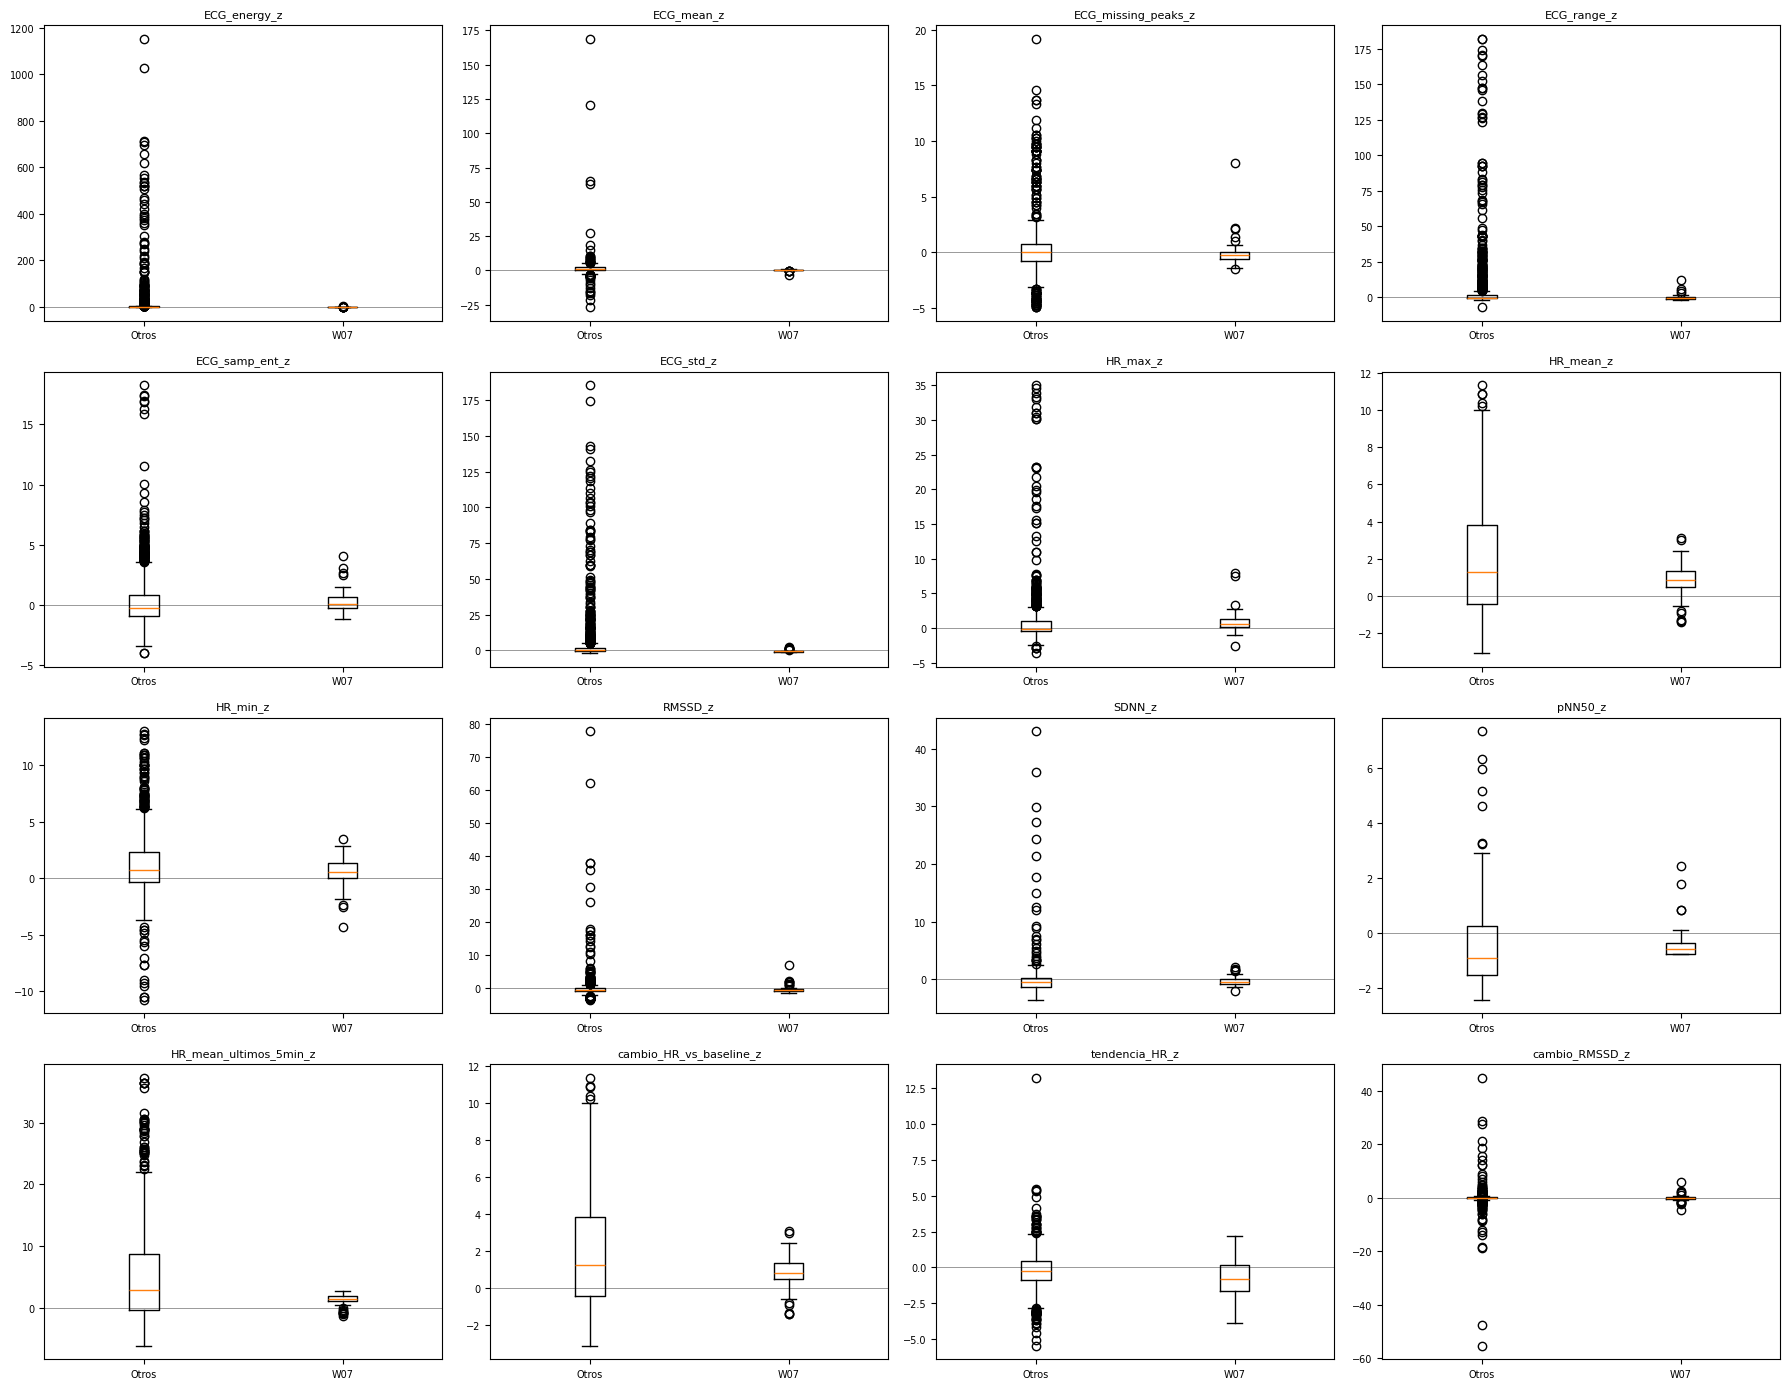

In [6]:
plot_data = all_data.copy()
plot_data['Group'] = np.where(plot_data.Worker == TARGET_WORKER, TARGET_WORKER, 'Otros')
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for axis, feature in zip(axes.flat, FEATURE_COLUMNS):
    values = [pd.to_numeric(plot_data.loc[plot_data.Group == 'Otros', feature], errors='coerce').dropna(), pd.to_numeric(plot_data.loc[plot_data.Group == TARGET_WORKER, feature], errors='coerce').dropna()]
    axis.boxplot(values, labels=['Otros', TARGET_WORKER], showfliers=True)
    axis.axhline(0, color='black', linewidth=.7, alpha=.4)
    axis.set_title(feature, fontsize=8)
    axis.tick_params(axis='both', labelsize=7)
plt.tight_layout(); plt.show()